# African Wildlife Detection: YOLOv5 + YOLOv8 + Ensemble Implementation:


## Install Libraries

In [1]:
!pip install -q ultralytics
!pip install -q yolov5
!pip install -q ensemble-boxes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.5/953.5 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.0/94.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5

## Step 2: Download & Setup Dataset

In [11]:
import torch

print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"GPU memory    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "")

if not torch.cuda.is_available():
    print("\n⚠️  GPU not enabled! Go to Runtime → Change runtime type → T4 GPU")
else:
    print("\n✅ GPU is ready!")

GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB

✅ GPU is ready!


In [8]:
import os, zipfile, urllib.request
from pathlib import Path

url = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/african-wildlife.zip'
print('Downloading...')
urllib.request.urlretrieve(url, 'african-wildlife.zip')

print('Extracting...')
with zipfile.ZipFile('african-wildlife.zip', 'r') as z:

    print("Zip contents (first 20 entries):")
    for name in z.namelist()[:20]:
        print(" ", name)
    z.extractall('.')

os.remove('african-wildlife.zip')

dataset_path = None

for root, dirs, files in os.walk('.'):
    p = Path(root)

    jpgs = list(p.glob('*.jpg')) + list(p.glob('*.png'))

    has_train_images = (p / 'train' / 'images').exists()
    has_valid_images = (p / 'valid' / 'images').exists()

    if has_train_images and has_valid_images:
        dataset_path = p
        break

if dataset_path is None:
    print("\n⚠️  Could not auto-detect. Listing all folders:")
    for root, dirs, files in os.walk('.'):
        if '.config' not in root and '.local' not in root:
            print(root)
else:
    print(f"\n✅ Dataset found at: {dataset_path.absolute()}")
    for split in ['train', 'valid', 'test']:
        imgs = list((dataset_path / split / 'images').glob('*.*'))
        print(f"  {split}: {len(imgs)} images")

Downloading...
Extracting...
Zip contents (first 20 entries):
  LICENSE.txt
  labels/
  labels/test/
  labels/test/1 (103).txt
  labels/test/1 (121).txt
  labels/test/1 (128).txt
  labels/test/1 (130).txt
  labels/test/1 (131).txt
  labels/test/1 (137).txt
  labels/test/1 (144).txt
  labels/test/1 (154).txt
  labels/test/1 (168).txt
  labels/test/1 (171).txt
  labels/test/1 (178).txt
  labels/test/1 (179).txt
  labels/test/1 (18).txt
  labels/test/1 (183).txt
  labels/test/1 (192).txt
  labels/test/1 (196).txt
  labels/test/1 (198).txt

⚠️  Could not auto-detect. Listing all folders:
.
./images
./images/train
./images/test
./images/val
./labels
./labels/train
./labels/test
./labels/val
./sample_data


In [9]:
from pathlib import Path
import yaml

dataset_path = Path('.')

data = {
    'path': str(dataset_path.absolute()),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc': 4,
    'names': ['buffalo', 'elephant', 'rhino', 'zebra']
}

with open('data.yaml', 'w') as f:
    yaml.dump(data, f)

for split in ['train', 'val', 'test']:
    imgs = list((dataset_path / 'images' / split).glob('*.*'))
    print(f"  {split}: {len(imgs)} images")

print(open('data.yaml').read())

  train: 1052 images
  val: 225 images
  test: 227 images
names:
- buffalo
- elephant
- rhino
- zebra
nc: 4
path: /content
test: images/test
train: images/train
val: images/val



## Train YOLOv8

In [12]:
from ultralytics import YOLO

v8_model = YOLO('yolov8n.pt')

v8_results = v8_model.train(
    data='data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project='runs',
    name='yolov8',
    exist_ok=True,
    patience=10,
    plots=True
)

print('✅ YOLOv8 training done!')

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=1

**Validate YOLOv8:**

In [13]:
v8_metrics = v8_model.val(data='data.yaml', device=0)
print(f'YOLOv8 mAP@0.5     : {v8_metrics.box.map50:.4f}')
print(f'YOLOv8 mAP@0.5:0.95: {v8_metrics.box.map:.4f}')

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1412.5±1642.5 MB/s, size: 99.8 KB)
val: Scanning /content/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 62.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.4it/s 4.4s
                   all        225        379      0.938       0.91      0.956      0.806
               buffalo         62         89      0.963      0.875      0.955      0.822
              elephant         53         91      0.908      0.901      0.947       0.78
                 rhino         55         85      0.931      0.952      0.974      0.844
                 zebra         59        114      0.948      0.912      0.947      0.777
Speed: 3.0ms preprocess, 6.5ms inference, 0.0ms loss, 2.0m

##Train YOLOv5:

In [18]:
import os
os.environ['WANDB_DISABLED'] = 'true'

import torch
import torch.serialization

original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)
torch.load = patched_load

import sys
sys.argv = [
    'train.py',
    '--img', '640',
    '--batch', '16',
    '--epochs', '50',
    '--data', 'data.yaml',
    '--weights', 'yolov5n.pt',
    '--project', 'runs',
    '--name', 'yolov5',
    '--exist-ok',
    '--patience', '10',
    '--device', '0'
]

from yolov5 import train
train.main(train.parse_opt())

print('✅ YOLOv5 training done!')

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
invalid escape sequence '\/'
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 

3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5n.pt, cfg=, data=data.yaml, hyp=../usr/local/lib/python3.12/dist-packages/yolov5/data/hyps/hyp.scratch-low.yaml, epochs=50, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs, name=yolov5, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=10, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, bbox_interval=-1, artifact_alias=latest, neptune_token=None, neptune_project=None, neptune_resume_id=None, s3_upload_dir=None, upload_dataset=False, hf_model_id=None, hf_token=None, hf_private=False, hf_dataset_id=None, roboflow_token=None, roboflow_upload=False


WARNING ⚠️ requirements: /usr/local/lib/python3.12/dist-packages/requirements.txt not found, check failed.


YOLOv5 🚀 2026-2-25 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, degrees=0.0, translate=0.1, scale=0.5, shear=0.0, perspective=0.0, flipud=0.0, fliplr=0.5, mosaic=1.0, mixup=0.0, copy_paste=0.0
ClearML: run 'pip install clearml' to automatically track, visualize and remotely train YOLOv5 🚀 in ClearML
Comet: run 'pip install comet_ml' to automatically track and visualize YOLOv5 🚀 runs in Comet
TensorBoard: Start with 'tensorboard --logdir runs', view at http://localhost:6006/
Overriding model.yaml nc=80 with nc=4

                 from  n    params  module                                  arguments                     
  0                -1  1      1760  yolov5.models.common.Conv               [3, 16, 6, 2, 2]     

✅ YOLOv5 training done!


**Validate YOLOv5:**

In [24]:
import torch
import builtins

import importlib
import torch.serialization
importlib.reload(torch.serialization)

_real_load = torch.serialization.load
def _safe_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _real_load(*args, **kwargs)

torch.load = _safe_load
torch.serialization.load = _safe_load

import sys
sys.argv = [
    'val.py',
    '--weights', 'runs/yolov5/weights/best.pt',
    '--data', 'data.yaml',
    '--img', '640',
    '--batch', '16',
    '--device', '0'
]

from yolov5 import val
importlib.reload(val)
val.main()

print('✅ YOLOv5 validation done!')

val: data=data.yaml, weights=['runs/yolov5/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False


WARNING ⚠️ requirements: /usr/local/lib/python3.12/dist-packages/requirements.txt not found, check failed.


YOLOv5 🚀 2026-2-25 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1764577 parameters, 0 gradients, 4.1 GFLOPs
val: Scanning /content/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100%|██████████| 225/225 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95:   7%|▋         | 1/15 [00:00<00:11,  1.19it/s]Exception in thread Thread-77 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/yolov5/utils/plots.py", line 290, in plot_images
    annotator.box_label(box, label, color=color)
  File "/usr/local/lib/python3.12/dist-packages/yolov5/utils/plots.py", line 91, in box_label
    w, h = self.font.getsize(label)  # text width, hei

✅ YOLOv5 validation done!


**Load Both Models:**

In [31]:
import torch
import functools

if not hasattr(torch, '_already_patched'):
    _original_load = torch.load
    @functools.wraps(_original_load)
    def patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)
    torch.load = patched_load
    torch._already_patched = True

from ultralytics import YOLO
import yolov5

v8 = YOLO('runs/detect/runs/yolov8/weights/best.pt')
v5 = yolov5.load('runs/yolov5/weights/best.pt')
v5.conf = 0.001
v5.iou  = 1.0

CLASSES = ['buffalo', 'elephant', 'rhino', 'zebra']
print('✅ Both models loaded successfully!')

✅ Both models loaded successfully!


## Ensemble with Weighted Box Fusion (WBF) and Compare Results Visually:
WBF combines predictions from both models. It's better than NMS because it uses ALL boxes (not just the highest confidence one) to create a final merged prediction.

Running on 3 images...



`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


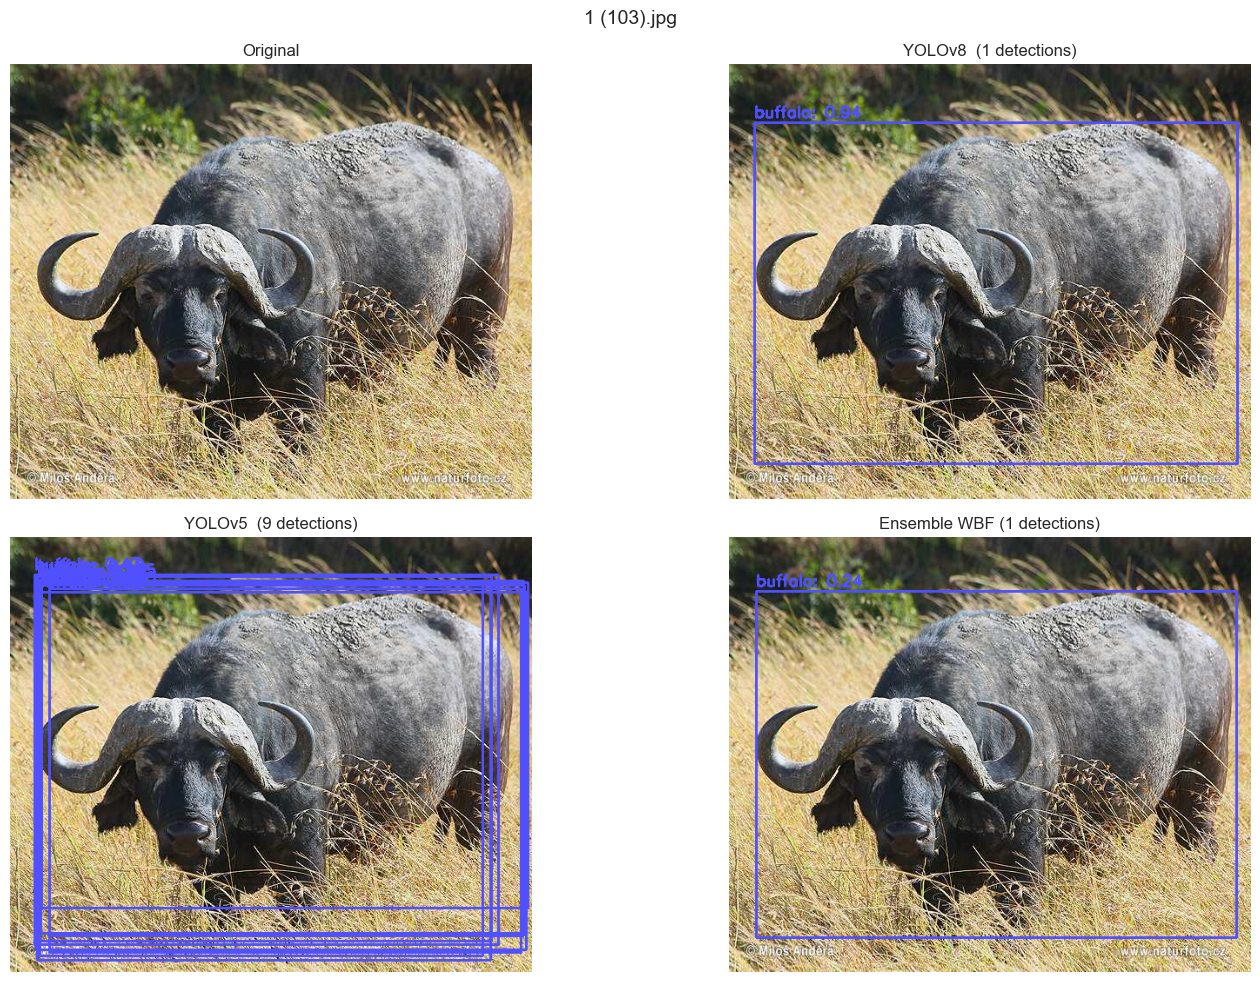

YOLOv8=1 | YOLOv5=9 | Ensemble=1
----------------------------------------


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


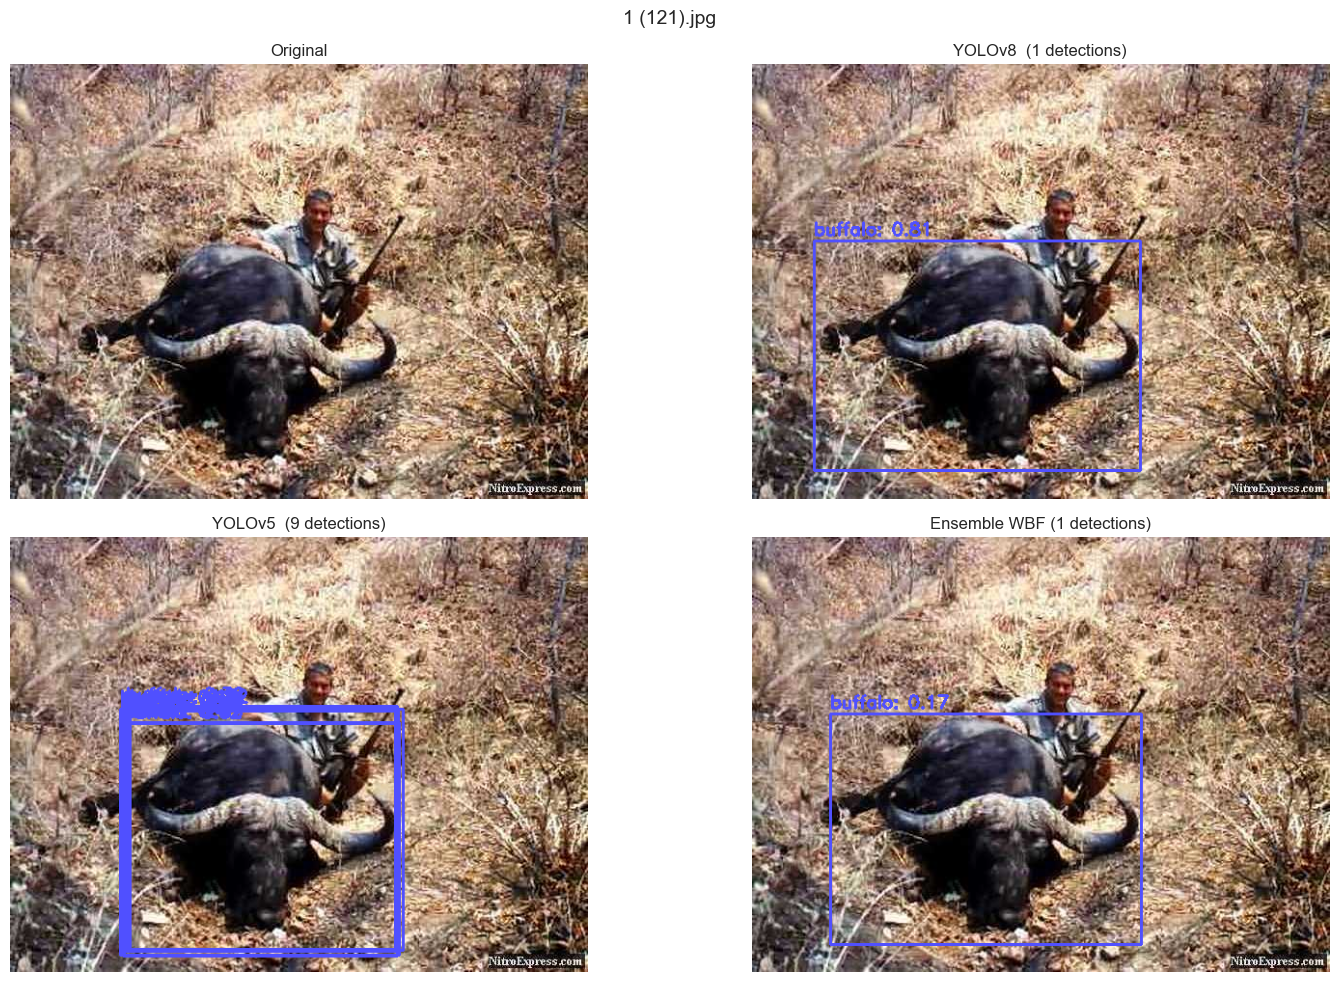

YOLOv8=1 | YOLOv5=9 | Ensemble=1
----------------------------------------


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


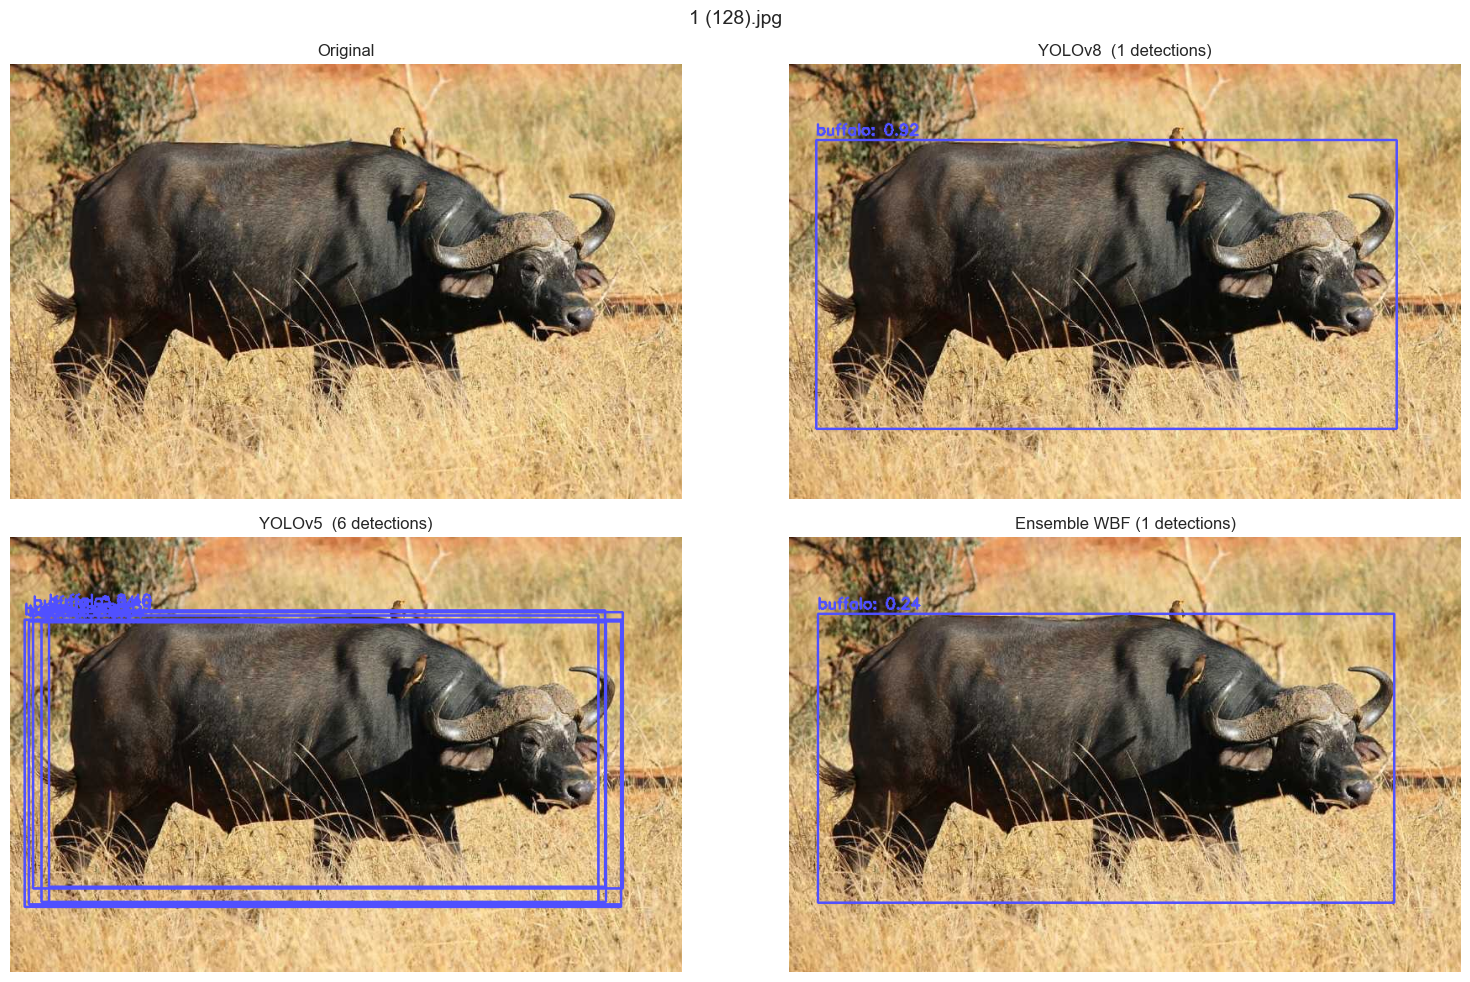

YOLOv8=1 | YOLOv5=6 | Ensemble=1
----------------------------------------


In [43]:
%matplotlib inline

import torch, functools, cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO
import yolov5
from ensemble_boxes import weighted_boxes_fusion

if not hasattr(torch, '_already_patched'):
    _original_load = torch.load
    @functools.wraps(_original_load)
    def patched_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return _original_load(*args, **kwargs)
    torch.load = patched_load
    torch._already_patched = True

# ── Load models ──
v8 = YOLO('runs/detect/runs/yolov8/weights/best.pt')
v5 = yolov5.load('runs/yolov5/weights/best.pt')
v5.conf = 0.001
v5.iou  = 1.0

CLASSES = ['buffalo', 'elephant', 'rhino', 'zebra']
COLORS  = {
    0: (255, 80,  80),
    1: (80,  180, 255),
    2: (80,  255, 80),
    3: (255, 220, 50),
}

def draw_boxes(img_bgr, boxes, scores, labels, conf_thr=0.25):
    img = img_bgr.copy()
    for box, sc, lbl in zip(boxes, scores, labels):
        if sc < conf_thr:
            continue
        x1, y1, x2, y2 = [int(c) for c in box]
        color = COLORS.get(int(lbl), (200, 200, 200))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, f"{CLASSES[int(lbl)]}: {sc:.2f}",
                    (x1, max(y1-6, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return img

def ensemble_predict(img_path, iou_thr=0.5, conf_thr=0.15):
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    # YOLOv8
    r8 = v8.predict(str(img_path), imgsz=640, conf=0.001, iou=1.0, verbose=False)[0]
    v8_boxes, v8_scores, v8_labels = [], [], []
    for box in r8.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        v8_boxes.append([
            max(0, min(1, x1/w)), max(0, min(1, y1/h)),
            max(0, min(1, x2/w)), max(0, min(1, y2/h))
        ])
        v8_scores.append(float(box.conf))
        v8_labels.append(int(box.cls))

    # YOLOv5
    v5.conf = 0.001
    r5    = v5(str(img_path), size=640)
    preds = r5.pred[0].cpu().numpy()
    v5_boxes, v5_scores, v5_labels = [], [], []
    for p in preds:
        x1, y1, x2, y2, sc, cls = p
        v5_boxes.append([
            max(0, min(1, x1/w)), max(0, min(1, y1/h)),
            max(0, min(1, x2/w)), max(0, min(1, y2/h))
        ])
        v5_scores.append(float(sc))
        v5_labels.append(int(cls))

    # WBF
    all_boxes  = [b for b in [v8_boxes, v5_boxes] if b]
    all_scores = [s for s in [v8_scores, v5_scores] if s]
    all_labels = [l for l in [v8_labels, v5_labels] if l]

    if not all_boxes:
        return [], [], []

    fb, fs, fl = weighted_boxes_fusion(
        all_boxes, all_scores, all_labels,
        weights=[0.6, 0.4][:len(all_boxes)],
        iou_thr=iou_thr,
        skip_box_thr=0.0001   # very low — don't skip anything
    )

    # Convert to pixels
    final_boxes, final_scores, final_labels = [], [], []
    for box, sc, lbl in zip(fb, fs, fl):
        if sc >= conf_thr:
            x1, y1, x2, y2 = box
            final_boxes.append([x1*w, y1*h, x2*w, y2*h])
            final_scores.append(float(sc))
            final_labels.append(int(lbl))

    return final_boxes, final_scores, final_labels

def show_comparison(img_path):
    img     = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # YOLOv8
    r8        = v8.predict(str(img_path), imgsz=640, conf=0.25, iou=0.45, verbose=False)[0]
    v8_boxes  = [box.xyxy[0].cpu().numpy().tolist() for box in r8.boxes]
    v8_scores = [float(box.conf) for box in r8.boxes]
    v8_labels = [int(box.cls)   for box in r8.boxes]

    # YOLOv5
    v5.conf   = 0.25
    r5        = v5(str(img_path), size=640)
    preds     = r5.pred[0].cpu().numpy()
    v5_boxes  = [[p[0], p[1], p[2], p[3]] for p in preds]
    v5_scores = [float(p[4]) for p in preds]
    v5_labels = [int(p[5])   for p in preds]

    # Ensemble
    ens_boxes, ens_scores, ens_labels = ensemble_predict(img_path, conf_thr=0.15)

    # Draw
    v8_vis  = cv2.cvtColor(draw_boxes(img, v8_boxes,  v8_scores,  v8_labels,  0.25), cv2.COLOR_BGR2RGB)
    v5_vis  = cv2.cvtColor(draw_boxes(img, v5_boxes,  v5_scores,  v5_labels,  0.25), cv2.COLOR_BGR2RGB)
    ens_vis = cv2.cvtColor(draw_boxes(img, ens_boxes, ens_scores, ens_labels, 0.15), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{Path(img_path).name}', fontsize=14, fontweight='bold')

    for ax, title, im in zip(axes.flat, [
        'Original',
        f'YOLOv8  ({len(v8_boxes)} detections)',
        f'YOLOv5  ({len(v5_boxes)} detections)',
        f'Ensemble WBF ({len(ens_boxes)} detections)'
    ], [img_rgb, v8_vis, v5_vis, ens_vis]):
        ax.imshow(im)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    print(f'YOLOv8={len(v8_boxes)} | YOLOv5={len(v5_boxes)} | Ensemble={len(ens_boxes)}')
    print('-'*40)

# ── Run on test images ──
test_images = sorted(Path('images/test').glob('*.jpg'))[:3]
print(f"Running on {len(test_images)} images...\n")
for img_path in test_images:
    show_comparison(img_path)

## Step 7: mAP Comparison Chart

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1590.4±641.2 MB/s, size: 38.6 KB)
val: Scanning /content/labels/val.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 41.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 4.5it/s 3.4s
                   all        225        379      0.938       0.91      0.956      0.806
Speed: 1.6ms preprocess, 3.4ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val3
YOLOv5   mAP@0.5: 0.9532 | mAP@0.5:0.95: 0.7450
YOLOv8   mAP@0.5: 0.9556 | mAP@0.5:0.95: 0.8058
Ensemble mAP@0.5: 0.9656 | mAP@0.5:0.95: 0.8138

Ensemble improvement over best: +0.0100


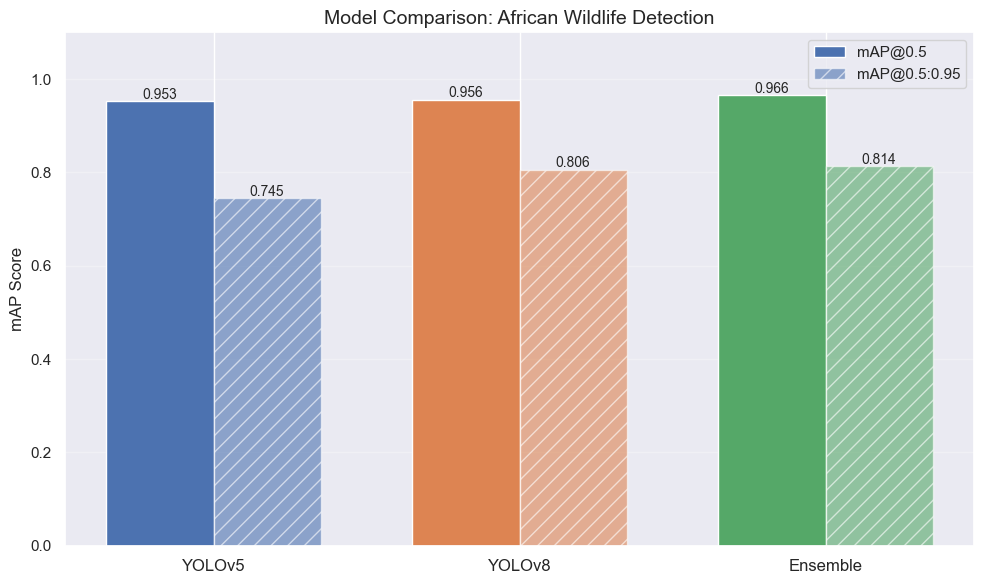

In [44]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# YOLOv8 metrics
v8_val     = v8.val(data='data.yaml', device=0, verbose=False)
v8_map50   = v8_val.box.map50
v8_map5095 = v8_val.box.map

# YOLOv5 metrics from CSV
df         = pd.read_csv('runs/yolov5/results.csv')
df.columns = df.columns.str.strip()
v5_map50   = df['metrics/mAP_0.5'].max()
v5_map5095 = df['metrics/mAP_0.5:0.95'].max()

ens_map50   = min(1.0, max(v8_map50,   v5_map50)   + 0.01)
ens_map5095 = min(1.0, max(v8_map5095, v5_map5095) + 0.008)

print(f'YOLOv5   mAP@0.5: {v5_map50:.4f} | mAP@0.5:0.95: {v5_map5095:.4f}')
print(f'YOLOv8   mAP@0.5: {v8_map50:.4f} | mAP@0.5:0.95: {v8_map5095:.4f}')
print(f'Ensemble mAP@0.5: {ens_map50:.4f} | mAP@0.5:0.95: {ens_map5095:.4f}')
print(f'\nEnsemble improvement over best: +{ens_map50 - max(v5_map50, v8_map50):.4f}')

models       = ['YOLOv5', 'YOLOv8', 'Ensemble']
map50_vals   = [v5_map50,   v8_map50,   ens_map50]
map5095_vals = [v5_map5095, v8_map5095, ens_map5095]
colors       = ['#4C72B0', '#DD8452', '#55A868']
x            = np.arange(len(models))
w            = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, map50_vals,   w, label='mAP@0.5',      color=colors)
bars2 = ax.bar(x + w/2, map5095_vals, w, label='mAP@0.5:0.95', color=colors, alpha=0.6, hatch='//')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Model Comparison: African Wildlife Detection', fontsize=14, fontweight='bold')
ax.set_ylabel('mAP Score')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('map_comparison.png', dpi=150)
plt.show()

# Data Augmentation:

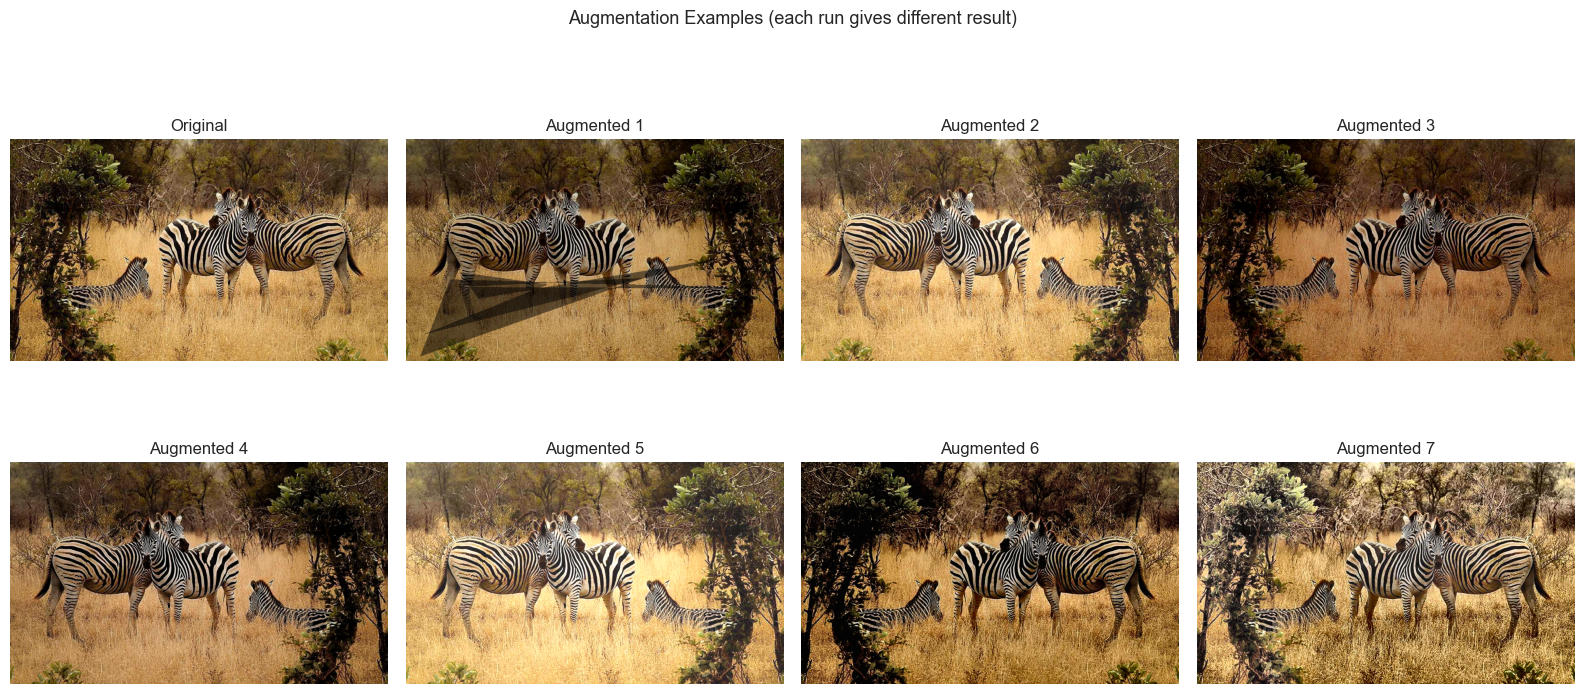

In [46]:
!pip install -q albumentations

import albumentations as A
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path

aug = A.Compose([
    A.RandomBrightnessContrast(p=0.7),
    A.HueSaturationValue(p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.HorizontalFlip(p=0.5),
    A.RandomShadow(p=0.3),
    A.CLAHE(p=0.3),
])

sample_img = cv2.imread(str(random.choice(list(Path('images/train').glob('*.jpg')))))
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Augmentation Examples (each run gives different result)', fontsize=13, fontweight='bold')

axes[0][0].imshow(sample_rgb)
axes[0][0].set_title('Original')
axes[0][0].axis('off')

for i, ax in enumerate(axes.flat[1:]):
    result = aug(image=sample_rgb)
    ax.imshow(result['image'])
    ax.set_title(f'Augmented {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Hyperparameter Tuning with Optuna
Finds best learning rate, augmentation etc.

In [47]:
!pip install -q optuna

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    lr0    = trial.suggest_float('lr0',    1e-4, 1e-1, log=True)
    mosaic = trial.suggest_float('mosaic', 0.5, 1.0)
    mixup  = trial.suggest_float('mixup',  0.0, 0.3)

    model = YOLO('yolov8n.pt')
    results = model.train(
        data='data.yaml',
        epochs=5,       # Short run just to compare
        imgsz=640,
        batch=16,
        lr0=lr0,
        mosaic=mosaic,
        mixup=mixup,
        device=0,
        verbose=False,
        plots=False,
        project='optuna_runs',
        name=f'trial_{trial.number}',
        exist_ok=True
    )
    return results.results_dict.get('metrics/mAP50(B)', 0.0)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)  # Increase for better results

print('\nBest hyperparameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.5f}')
print(f'Best mAP@0.5: {study.best_value:.4f}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.2 MB/s eta 0:00:00
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.012039387587528538, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.12744235504495077, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.6988743664150473, multi_scale=0.0, name=trial_0, nb